# Programmes du programme de terminale

## Suites
### Somme des termes d'une suite
Déterminer $\displaystyle\sum_{k=1}^n\dfrac{k^2}{4^k}=\dfrac{1^2}{4^1}+\dfrac{2^2}{4^2}+\cdots+\dfrac{n^2}{4^n}$.

In [1]:
def somme(n):
    S = 0
    for k in range(1, n + 1):
        S = S + k**2/4**k
    return S

somme(1000)

0.7407407407407407

**Notation `+=`**

In [2]:
def somme(n):
    S = 0
    for k in range(1, n + 1):
        S += k**2/4**k
    return S

somme(1000)

0.7407407407407407

**Utilisation d'une boucle `while`**

In [4]:
def somme(n):
    S = 1/4
    k = 1
    while k < n:
        k += 1 
        S += k**2/4**k
        
    return S

somme(1000)

0.7407407407407407

## Dénombrement et probabilités
### Factorielles
Calculer $n!$ où $n$ est un entier naturel.

In [8]:
def factorielle(n):
    resultat = 1
    for k in range(1, n + 1):
        resultat *= k
    return resultat

factorielle(6)

720

**Utilisation de `while`**

In [9]:
def factorielle(n):
    resultat = 1
    k = 1
    while k < n:
        k += 1
        resultat *= k
    return resultat

factorielle(6)

720

**Utilisation de `while` (bis)**

In [10]:
def factorielle(n):
    if n == 0:
        return 1
    resultat = n
    while n > 1:
        n -= 1
        resultat *= n
    return resultat

factorielle(6)

720

**Fonction récursive**

In [12]:
def factorielle(n):
    if n == 0:
        return 1
    else:
        return n * factorielle(n - 1)

factorielle(6)

720

### Calcul des coefficients binomiaux
Déterminer $\displaystyle\binom{n}{k}$ où $k$ et $n$ sont des entiers naturels avec $k\leq n$.

In [23]:
def binom(n, k):
    if n == 0 or k == 0 or n == k:
        return 1
    if k > n//2:
        k = n - k
    resultat = n
    for i in range(2, k+1):
        resultat *= n - i + 1
        resultat //= i
    return resultat

binom(7, 3)

35

### Formule de Pascal
Déterminer $\displaystyle\binom{n}{k}$ en utilisant la formule de Pascal.

In [25]:
def binom(n, k):
    if k == 0 or k == n:
        return 1
    else:
        return binom(n - 1, k - 1) + binom(n - 1, k)

binom(7, 3)

35

### Triangle de Pascal
Soit $n$ un entier naturel. Donner sous forme de liste la ligne $n$ du triangle de Pascal.

In [24]:
def triangle_pascal(n):
    if n == 0:
        return [1]
    ligne = triangle_pascal(n - 1)
    ligne_suivante = [1]
    for i in range(n - 1):
        ligne_suivante.append(ligne[i] + ligne[i + 1])
    ligne_suivante.append(1)
    return ligne_suivante

triangle_pascal(5)

[1, 5, 10, 10, 5, 1]

### Simulation d'une loi binomiale
Simuler la répétition de $n$ épreuves de Bernoulli identiques et indépendantes de paramètre $p$. Compter le nombre de succès

In [27]:
from random import random

def bernoulli(n, p):
    succes = 0
    for i in range(n):
        if random() < p:
            succes += 1
    return succes

bernoulli(100, 0.3)

33

In [28]:
def loi_binomiale(n, p, nombre_de_simulations):
    loi_simulee = [0 for _ in range(n + 1)]
    for _ in range(nombre_de_simulations):
        k = bernoulli(n, p)
        loi_simulee[k] += 1
    return [x / nombre_de_simulations for x in loi_simulee]

loi_binomiale(10, 0.3, 10000)

[0.0307,
 0.1216,
 0.2334,
 0.2772,
 0.192,
 0.0999,
 0.036,
 0.0081,
 0.0011,
 0.0,
 0.0]

In [33]:
from scipy.stats import binom

n = 10
p = 0.3

valeurs = list(range(n + 1))
probabilites = binom.pmf(valeurs, n, p)

print(probabilites)

[2.82475249e-02 1.21060821e-01 2.33474441e-01 2.66827932e-01
 2.00120949e-01 1.02919345e-01 3.67569090e-02 9.00169200e-03
 1.44670050e-03 1.37781000e-04 5.90490000e-06]


### Marche aléatoire
Simuler et représenter une marche aléatoire en une dimension $\{-1,+1\}$ avec une probabilité $p$ de $+1$.

In [38]:
from random import random

def marche_aleatoire(n, p):
    position = 0
    marche = [position]
    for _ in range(n):
        if random() < p:
            position += 1
        else:
            position -= 1
        marche.append(position)
    return marche

marche_aleatoire(20, 0.5)

[0, -1, -2, -1, -2, -3, -2, -3, -4, -5, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 2]

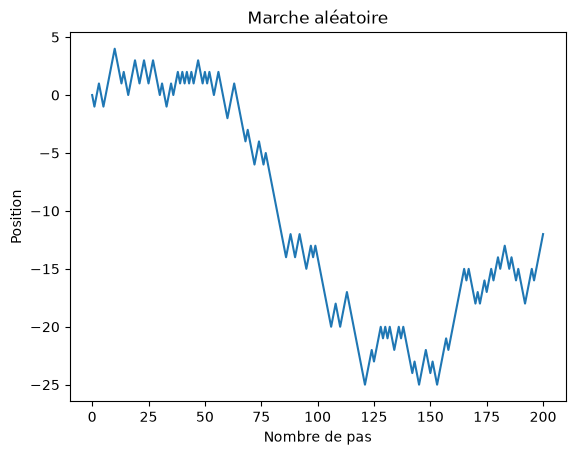

In [40]:
import matplotlib.pyplot as plt

plt.plot(marche_aleatoire(200, 0.5))
plt.title("Marche aléatoire")
plt.xlabel("Nombre de pas")
plt.ylabel("Position")
plt.show()

## Intégrales
### Méthode des rectangles à gauche
Soit $f$ une fonction continue sur un intervalle $[a,b]$. Déterminer une valeur approchée de $\displaystyle\int_a^bf(x)\,\text{d}x$ par la méthode des rectangles à gauche.

In [44]:
def integrale_rect_gauche(f, a, b, n):
    h = (b - a) / n
    somme = 0
    for k in range(n):
        somme += f(a + k * h)
    return somme * h

def f(x):
    return x**2

integrale_rect_gauche(f, 0, 2, 1000)

2.6626679999999996

Dans le cas de cet exemple, la valeur théorique est de $\dfrac{8}{3}\approx2,666666666666667$.

### Méthode des rectangles (point du milieu)

In [45]:
def integrale_rect_milieu(f, a, b, n):
    h = (b - a) / n
    somme = 0
    for k in range(n):
        somme += f(a + (k + 0.5) * h)
    return somme * h

def f(x):
    return x**2

integrale_rect_milieu(f, 0, 2, 1000)

2.6666659999999998

### Méthode de Monte-Carlo
On suppose ici que $f$ est positive sur $[a,b]$.

In [50]:
from random import random

def integrale_monte_carlo(f, a, b, Max, n):
    nb_points = 0
    for _ in range(n):
        x = random() * (b - a) + a
        y = random() * Max
        if y <= f(x):
            nb_points += 1
    return Max * (b - a) * nb_points / n 

integrale_monte_carlo(f, 0, 2, 4, 10000)

2.6312

### Valeur approchée de $\pi$ par la méthode de Monte-Carlo

In [52]:
from random import random

def pi_Monte_Carlo(n):
    nb_points = 0
    for _ in range(n):
        x = random()
        y = random()
        if x**2 + y**2 <= 1:
            nb_points += 1
    return 4 * nb_points / n

pi_Monte_Carlo(10000)

3.1556

## Equations
### Méthode de Newton
Soit $f$ une fonction définie et dérivable sur un intervalle $[a,b]$. On suppose que :
- l'équation $f(x)=0$ admet une unique solution sur $[a,b]$ ;
- $f'(x)\neq0$ sur $[a,b]$.
Déterminer une valeur approchée de la solution de l'équation $f(x)=0$ par la méthode de Newton (en supposant qu'elle converge).

In [54]:
def newton(f, f_p, x0, max_iter=100, tol=1e-7):
    x = x0
    for _ in range(max_iter):
        x_new = x - f(x) / f_p(x)
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return x

def f(x):
    return x**3 + x - 1

def f_p(x):
    return 3*x**2 + 1

newton(f, f_p, 0.5)

0.6823278038280194